In [1]:
import geopandas as gpd
import pandas as pd


#Read in shapefile tags
irradiation = gpd.read_file("/fs9/eliviau/hex2vec_project/Eli_test/ELIS_PROJECT/MCDM_project/outputs and maps/hokkaido_ahp_irradiationreso7.geojson") #specify which tags to use
slope = gpd.read_file("/fs9/eliviau/hex2vec_project/Eli_test/ELIS_PROJECT/MCDM_project/outputs and maps/hokkaido_ahp_slopereso7.geojson") #specify which tags to use
aspect = gpd.read_file("/fs9/eliviau/hex2vec_project/Eli_test/ELIS_PROJECT/MCDM_project/outputs and maps/hokkaido_ahp_aspecreso7.geojson") #specify which tags to use
landcover = gpd.read_file("/fs9/eliviau/hex2vec_project/Eli_test/ELIS_PROJECT/MCDM_project/outputs and maps/hokkaido_ahp_landcoverreso7fortechFINAL.geojson") #specify which tags to use
road = gpd.read_file("/fs9/eliviau/hex2vec_project/ahp_road_density.geojson") #specify which tags to use

In [2]:
irradiation.head()

,region_id,ahp_solar_score,geometry
0,872e1a98bffffff,9.0,"POLYGON ((142.84128 42.90509, 142.83732 42.917..."
1,872ee4416ffffff,NaN,"POLYGON ((139.89816 41.93177, 139.89386 41.943..."
2,872ee4410ffffff,NaN,"POLYGON ((139.87211 41.92521, 139.8678 41.9373..."
3,872ee48d1ffffff,NaN,"POLYGON ((139.66424 41.31788, 139.65995 41.33,..."
4,872e1b468ffffff,9.0,"POLYGON ((141.24457 43.15301, 141.24037 43.165..."


In [3]:
slope.head()

,region_id,slope_score,geometry
0,872e1e366ffffff,8.272727,"POLYGON ((142.9675 42.27646, 142.96359 42.2888..."
1,872eadcc6ffffff,10.000000,"POLYGON ((144.31114 43.59698, 144.30735 43.609..."
2,872ef6c4affffff,8.461538,"POLYGON ((142.18504 44.97308, 142.18085 44.985..."
3,872ee4160ffffff,0.000000,"POLYGON ((139.54847 41.32813, 139.54416 41.340..."
4,872e1a40bffffff,7.666667,"POLYGON ((142.72862 43.57468, 142.7246 43.587,..."


In [4]:
aspect.head()

,region_id,ahp_score,geometry
0,872e1a48dffffff,2.062500,"POLYGON ((142.7959 43.68876, 142.79188 43.7010..."
1,872e1bd5affffff,1.142857,"POLYGON ((141.62557 42.8071, 141.62145 42.8193..."
2,872e1b2a9ffffff,7.142857,"POLYGON ((140.6523 43.0099, 140.64803 43.02204..."
3,872ef6b9bffffff,1.000000,"POLYGON ((141.75368 44.77449, 141.74944 44.786..."
4,872e122d5ffffff,6.750000,"POLYGON ((145.61117 43.17965, 145.60759 43.192..."


In [5]:
landcover.head()

,region_id,landcover_score,geometry
0,872ea8b8effffff,4.0,"POLYGON ((144.13318 44.27438, 144.12933 44.286..."
1,872ef0d06ffffff,4.0,"POLYGON ((141.25121 44.57662, 141.24692 44.588..."
2,872ef2b85ffffff,4.0,"POLYGON ((140.79938 45.41073, 140.79497 45.422..."
3,872ef5a35ffffff,NaN,"POLYGON ((139.99553 43.26175, 139.99115 43.273..."
4,872ef6a10ffffff,4.0,"POLYGON ((141.65479 44.71187, 141.65055 44.724..."


In [6]:
road.head()

,region_id,road_score,geometry
0,872e1bb05ffffff,0.000000,"POLYGON ((141.02832 42.42758, 141.02413 42.439..."
1,872ef415effffff,0.000000,"POLYGON ((141.48608 43.86309, 141.48187 43.875..."
2,872ef4690ffffff,0.000000,"POLYGON ((141.4078 44.51549, 141.40353 44.5276..."
3,872e1e645ffffff,1.551026,"POLYGON ((143.06589 42.7557, 143.06197 42.7681..."
4,872ea9cb2ffffff,0.000000,"POLYGON ((143.58632 44.41595, 143.58238 44.428..."


In [7]:
aspect = aspect.rename(columns={"ahp_score": "aspect_score"})

In [8]:
from functools import reduce

dfs = [slope, aspect, irradiation, landcover, road]

# Only keep useful columns to avoid geometry conflicts
for df in dfs:
    df.drop(columns="geometry", inplace=True)

# Merge all together on region_id
merged = reduce(lambda left, right: pd.merge(left, right, on="region_id", how="outer"), dfs)


In [9]:
merged.head()

,region_id,slope_score,aspect_score,ahp_solar_score,landcover_score,road_score
0,872e1e366ffffff,8.272727,4.785714,9.000000,5.333333,0.883549
1,872eadcc6ffffff,10.000000,3.400000,6.000000,4.000000,0.000000
2,872ef6c4affffff,8.461538,2.529412,4.333333,6.318182,0.000000
3,872ee4160ffffff,0.000000,1.000000,NaN,4.000000,0.000000
4,872e1a40bffffff,7.666667,0.312500,7.000000,5.818182,1.097839


In [ ]:
weights = {
    "ahp_solar_score": 0.16,
    "slope_score": 0.19,
    "aspect_score": 0.12,
    "landcover_score": 0.26,
    "road_score": 0.15
}


In [11]:
merged["ahp_total_score"] = sum(
    merged[col] * weight for col, weight in weights.items()
)


In [12]:
merged.head()

,region_id,slope_score,aspect_score,ahp_solar_score,landcover_score,road_score,ahp_total_score
0,872e1e366ffffff,8.272727,4.785714,9.000000,5.333333,0.883549,5.075909
1,872eadcc6ffffff,10.000000,3.400000,6.000000,4.000000,0.000000,4.248000
2,872ef6c4affffff,8.461538,2.529412,4.333333,6.318182,0.000000,4.225849
3,872ee4160ffffff,0.000000,1.000000,NaN,4.000000,0.000000,NaN
4,872e1a40bffffff,7.666667,0.312500,7.000000,5.818182,1.097839,4.273085


In [13]:
#join geometry back

#reload anyone of the datasets to get one with geometry
slope = gpd.read_file("/fs9/eliviau/hex2vec_project/Eli_test/ELIS_PROJECT/MCDM_project/outputs and maps/hokkaido_ahp_slopereso7.geojson") #specify which tags to use

#extract geometry from slope and merge it back to the merged dataframe
slope_geometry = slope[["region_id", "geometry"]]
final = merged.merge(slope_geometry, on="region_id", how="left")
final = gpd.GeoDataFrame(final, geometry="geometry", crs=slope.crs)

final.head()

,region_id,slope_score,aspect_score,ahp_solar_score,landcover_score,road_score,ahp_total_score,geometry
0,872e1e366ffffff,8.272727,4.785714,9.000000,5.333333,0.883549,5.075909,"POLYGON ((142.9675 42.27646, 142.96359 42.2888..."
1,872eadcc6ffffff,10.000000,3.400000,6.000000,4.000000,0.000000,4.248000,"POLYGON ((144.31114 43.59698, 144.30735 43.609..."
2,872ef6c4affffff,8.461538,2.529412,4.333333,6.318182,0.000000,4.225849,"POLYGON ((142.18504 44.97308, 142.18085 44.985..."
3,872ee4160ffffff,0.000000,1.000000,NaN,4.000000,0.000000,NaN,"POLYGON ((139.54847 41.32813, 139.54416 41.340..."
4,872e1a40bffffff,7.666667,0.312500,7.000000,5.818182,1.097839,4.273085,"POLYGON ((142.72862 43.57468, 142.7246 43.587,..."


In [14]:
final.head()

,region_id,slope_score,aspect_score,ahp_solar_score,landcover_score,road_score,ahp_total_score,geometry
0,872e1e366ffffff,8.272727,4.785714,9.000000,5.333333,0.883549,5.075909,"POLYGON ((142.9675 42.27646, 142.96359 42.2888..."
1,872eadcc6ffffff,10.000000,3.400000,6.000000,4.000000,0.000000,4.248000,"POLYGON ((144.31114 43.59698, 144.30735 43.609..."
2,872ef6c4affffff,8.461538,2.529412,4.333333,6.318182,0.000000,4.225849,"POLYGON ((142.18504 44.97308, 142.18085 44.985..."
3,872ee4160ffffff,0.000000,1.000000,NaN,4.000000,0.000000,NaN,"POLYGON ((139.54847 41.32813, 139.54416 41.340..."
4,872e1a40bffffff,7.666667,0.312500,7.000000,5.818182,1.097839,4.273085,"POLYGON ((142.72862 43.57468, 142.7246 43.587,..."


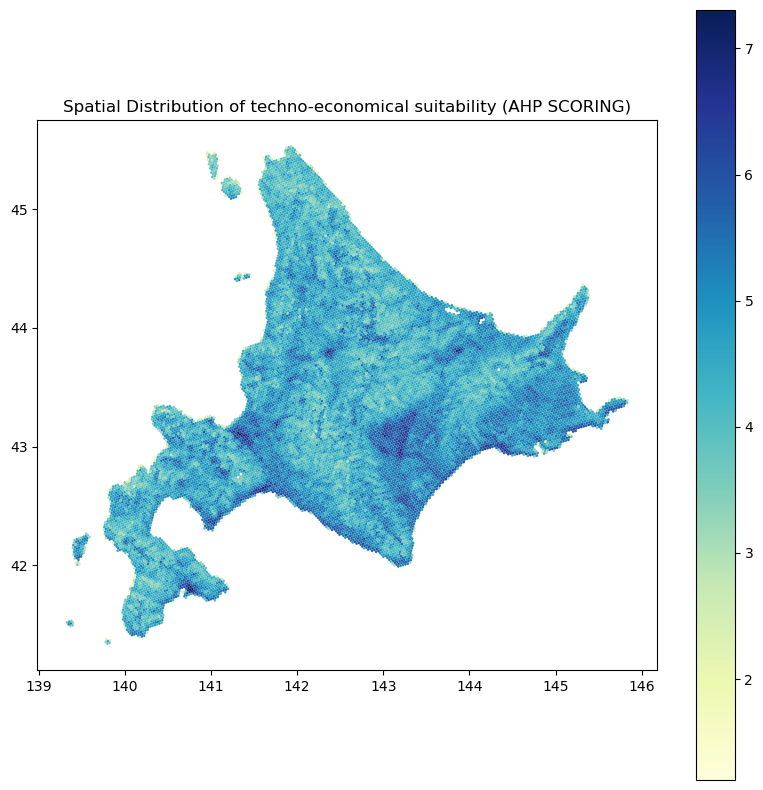

In [15]:
#first vizualise one quick map

from matplotlib import pyplot as plt

final.plot(
    column='ahp_total_score',
    cmap='YlGnBu',
    legend=True,
    figsize=(10,10)
)
plt.title("Spatial Distribution of techno-economical suitability (AHP SCORING)")
plt.show()


/tmp/ipykernel_96501/1545741786.py:39: UserWarning: This figure includes Axes that are not compatible with tight_layout, so results might be incorrect.
  plt.tight_layout()


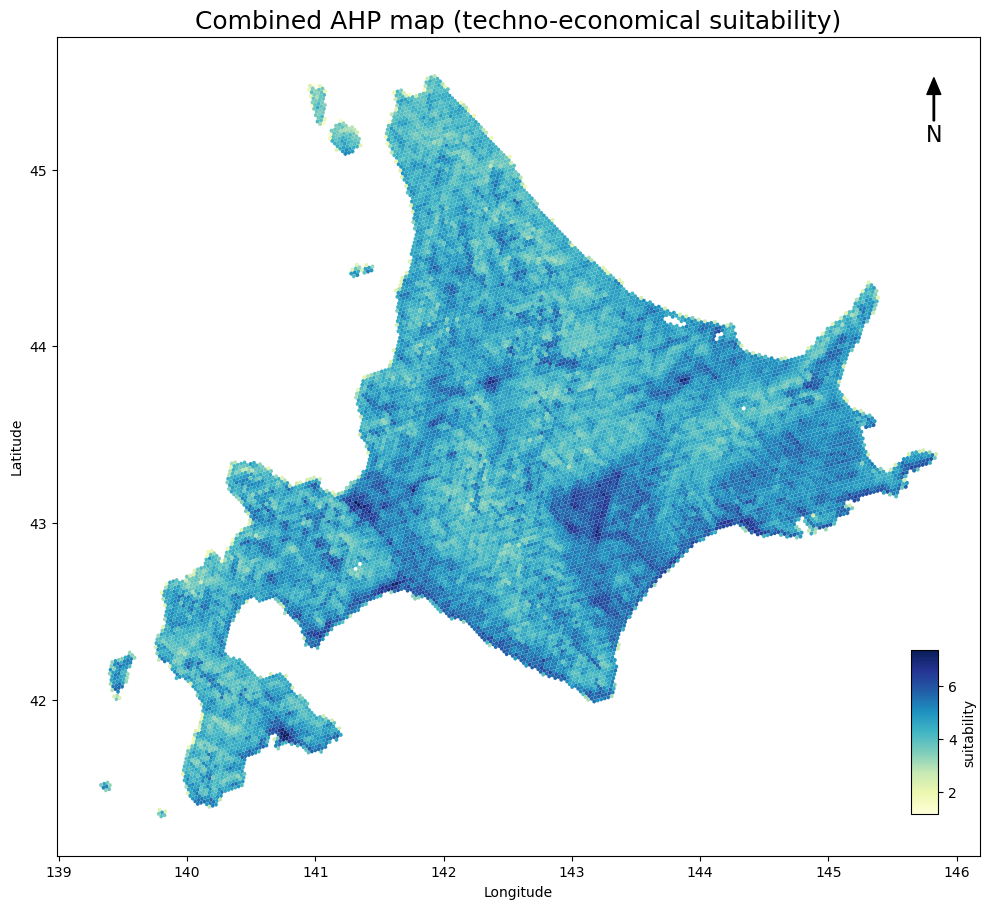

In [25]:
import geopandas as gpd
import matplotlib.pyplot as plt
from mpl_toolkits.axes_grid1.inset_locator import inset_axes


# 1. Create plot
fig, ax = plt.subplots(figsize=(10, 10))

# 2. Plot main map
main_plot = final.plot(
    column='ahp_total_score',
    cmap='YlGnBu',
    legend=False,  # We'll add a custom one
    ax=ax,
    edgecolor='none'
)

# 3. Add colorbar INSIDE the plot area
sm = plt.cm.ScalarMappable(cmap='YlGnBu', norm=plt.Normalize(vmin=final['ahp_total_score'].min(), vmax=final['ahp_total_score'].max()))
sm._A = []

cax = inset_axes(ax, width="3%", height="20%", loc='lower right', borderpad=3)  # Adjust size/position here
cbar = fig.colorbar(sm, cax=cax, orientation='vertical')
cbar.set_label("suitability")

# 4. Coordinate grid and title
ax.set_xlabel("Longitude")
ax.set_ylabel("Latitude")
ax.set_title("Combined AHP map (techno-economical suitability)", fontsize=18)

# Add north arrow but arrow shorter
ax.annotate('N',
            xy=(0.95, 0.95), xytext=(0.95, 0.88),
            xycoords='axes fraction',
            ha='center', va='center',
            fontsize=16,
            arrowprops=dict(facecolor='black', width=1, headwidth=10)) 

plt.tight_layout()
plt.show()


In [26]:
final.head()

,region_id,slope_score,aspect_score,ahp_solar_score,landcover_score,road_score,ahp_total_score,geometry
0,872e1e366ffffff,8.272727,4.785714,9.000000,5.333333,0.883549,5.105303,"POLYGON ((142.9675 42.27646, 142.96359 42.2888..."
1,872eadcc6ffffff,10.000000,3.400000,6.000000,4.000000,0.000000,4.308000,"POLYGON ((144.31114 43.59698, 144.30735 43.609..."
2,872ef6c4affffff,8.461538,2.529412,4.333333,6.318182,0.000000,4.247282,"POLYGON ((142.18504 44.97308, 142.18085 44.985..."
3,872ee4160ffffff,0.000000,1.000000,NaN,4.000000,0.000000,NaN,"POLYGON ((139.54847 41.32813, 139.54416 41.340..."
4,872e1a40bffffff,7.666667,0.312500,7.000000,5.818182,1.097839,4.291570,"POLYGON ((142.72862 43.57468, 142.7246 43.587,..."


In [16]:
#regions_scored save to output
final.to_file("/fs9/eliviau/hex2vec_project/Eli_test/ELIS_PROJECT/MCDM_project/outputs and maps/ahp_technoecon_totalscore_hokkaido2.geojson", driver="GeoJSON")

In [11]:
#Now create map with srai plotting tools and save

from srai.plotting import plot_numeric_data

#remettre le index 
final = final.set_index("region_id")

m = plot_numeric_data(final, "ahp_total_score", colormap="YlGnBu", opacity=0.6)
m.save("ahp_totalscore_hokkaido_mapreso7.html")


## ANALYZE GAP WITH GROUND TRUTH

In [16]:
#CLASSIFICATION ENVIRONMENT STARTS HERE

#Read in solar plant location and create prefecture mappings for readability

import geopandas as gpd
import pandas as pd


stations_gdf = ...

#Path for solar PV ground truth data
#Reading in training dataset
data_path = '/home/janelle9/Japan-GIS-Data/camila.csv'
stations_raw = pd.read_csv(data_path)
stations_gdf = gpd.GeoDataFrame(
    stations_raw,
    geometry=gpd.GeoSeries.from_xy(stations_raw["longitude"], stations_raw["latitude"]),
    crs="EPSG:4326",
)

#Reading in our validation dataset
data_path = "/home/janelle9/Japan-GIS-Data/validation.csv"
validation_raw = pd.read_csv(data_path)
validation_gdf = gpd.GeoDataFrame(
    stations_raw,
    geometry=gpd.GeoSeries.from_xy(stations_raw["longitude"], stations_raw["latitude"]),
    crs="EPSG:4326",
)


#Define regions of Japan
regional_prefectures = {
    "Hokkaido": ["Hokkaido"],
    "Tohoku":["Akita", "Aomori", "Fukushima", "Iwate", "Miyagi", "Yamagata"],
    "Chugoku": ["Hiroshima", "Okayama", "Shimane", "Tottori", "Yamaguchi"],
    "Kansai": ["Kyoto", "Shiga", "Osaka", "Nara", "Mie", "Wakayama", "Hyogo"],
    "Chubu": ["Niigata", "Toyama", "Ishikawa", "Fukui", "Yamanashi", "Nagano", "Gifu", "Shizuoka", "Aichi"],
    "Kanto": ["Ibaraki", "Tochigi", "Gunma", "Saitama", "Chiba", "Tokyo", "Kanagawa"],
    "Shikoku": ["Tokushima", "Kagawa", "Ehime", "Kochi"],
    "Kyushu": ["Fukuoka", "Saga", "Nagasaki", "Kumamoto", "Oita", "Miyazaki", "Kagoshima", "Okinawa"]   
}

#mappings are based on Japan ISO coding, these mappings are used in conjunction with our srai.regionalizers
prefecture_mapping = {
    1: "Hokkaido", 2: "Aomori", 3: "Iwate", 4: "Miyagi", 5: "Akita",
    6: "Yamagata", 7: "Fukushima", 8: "Ibaraki", 9: "Tochigi", 10: "Gunma",
    11: "Saitama", 12: "Chiba", 13: "Tokyo", 14: "Kanagawa", 15: "Niigata",
    16: "Toyama", 17: "Ishikawa", 18: "Fukui", 19: "Yamanashi", 20: "Nagano",
    21: "Gifu", 22: "Shizuoka", 23: "Aichi", 24: "Mie", 25: "Shiga",
    26: "Kyoto", 27: "Osaka", 28: "Hyogo", 29: "Nara", 30: "Wakayama",
    31: "Tottori", 32: "Shimane", 33: "Okayama", 34: "Hiroshima",
    35: "Yamaguchi", 36: "Tokushima", 37: "Kagawa", 38: "Ehime", 39: "Kochi",
    40: "Fukuoka", 41: "Saga", 42: "Nagasaki", 43: "Kumamoto",
    44: "Oita", 45: "Miyazaki", 46: "Kagoshima", 47: "Okinawa"
}

#Create a dataframe containing all PV locations, sort by prefecture
stations_gdf['prefecture'] = stations_gdf['prefecture'].map(prefecture_mapping) 

stations_gdf.head()



,ID,prefecture,latitude,longitude,power,geometry
0,3,Wakayama,34.271913,135.135274,1.3020,POINT (135.13527 34.27191)
1,7,Wakayama,34.279023,135.141710,2.7940,POINT (135.14171 34.27902)
2,8,Wakayama,34.182374,135.210084,1.6000,POINT (135.21008 34.18237)
3,9,Wakayama,34.280621,135.098882,21.0000,POINT (135.09888 34.28062)
4,10,Wakayama,34.290981,135.084250,23.9424,POINT (135.08425 34.29098)


In [17]:
#Cell A2
# #run this code to select a single prefecture
from srai.regionalizers import geocode_to_region_gdf

#download region data
select_prefecture = "Hokkaido"
geocode_to_region_string = str(select_prefecture + " Prefecture, Japan")
print(geocode_to_region_string)
prefecture = geocode_to_region_gdf(geocode_to_region_string)

power_plants = stations_gdf[(stations_gdf['prefecture'] == select_prefecture)]



Hokkaido Prefecture, Japan


/home/eliviau/miniconda3/envs/hex2vec_env/lib/python3.9/site-packages/networkx/utils/backends.py:135: RuntimeWarning: networkx backend defined more than once: nx-loopback
  backends.update(_get_backends("networkx.backends"))


In [58]:
power_plants.head()

,ID,prefecture,latitude,longitude,power,geometry
42,85,Hokkaido,41.926540,140.149396,1.10592,POINT (140.1494 41.92654)
43,89,Hokkaido,41.909399,140.153836,2.35530,POINT (140.15384 41.9094)
44,106,Hokkaido,43.198158,140.775253,1.98016,POINT (140.77525 43.19816)
45,111,Hokkaido,42.948497,141.814784,1.20400,POINT (141.81478 42.9485)
46,112,Hokkaido,43.050081,141.804632,0.92400,POINT (141.80463 43.05008)


In [18]:
final.head()

,region_id,slope_score,aspect_score,ahp_solar_score,landcover_score,road_score,ahp_total_score,geometry
0,872e1e366ffffff,8.272727,4.785714,9.000000,5.333333,0.883549,5.075909,"POLYGON ((142.9675 42.27646, 142.96359 42.2888..."
1,872eadcc6ffffff,10.000000,3.400000,6.000000,4.000000,0.000000,4.248000,"POLYGON ((144.31114 43.59698, 144.30735 43.609..."
2,872ef6c4affffff,8.461538,2.529412,4.333333,6.318182,0.000000,4.225849,"POLYGON ((142.18504 44.97308, 142.18085 44.985..."
3,872ee4160ffffff,0.000000,1.000000,NaN,4.000000,0.000000,NaN,"POLYGON ((139.54847 41.32813, 139.54416 41.340..."
4,872e1a40bffffff,7.666667,0.312500,7.000000,5.818182,1.097839,4.273085,"POLYGON ((142.72862 43.57468, 142.7246 43.587,..."


In [19]:
import geopandas as gpd

# 1. Vérifier que les deux jeux ont le même CRS
power_plants = power_plants.to_crs(final.crs)

# 2. Spatial join : associe chaque centrale solaire à l'hexagone dans lequel elle tombe
joined = gpd.sjoin(power_plants, final[["region_id", "geometry"]], how="left", predicate="within")

# 3. Créer une colonne binaire : 1 si au moins une centrale dans l’hexagone, sinon 0
# Récupère les region_id où une centrale est présente
regions_with_plant = joined["region_id"].dropna().unique()

# 4. Ajouter la colonne binaire à ton GeoDataFrame
final["SPP_presence"] = final["region_id"].apply(lambda x: 1 if x in regions_with_plant else 0)

# 5. Vérifie le résultat
final.head()


,region_id,slope_score,aspect_score,ahp_solar_score,landcover_score,road_score,ahp_total_score,geometry,SPP_presence
0,872e1e366ffffff,8.272727,4.785714,9.000000,5.333333,0.883549,5.075909,"POLYGON ((142.9675 42.27646, 142.96359 42.2888...",0
1,872eadcc6ffffff,10.000000,3.400000,6.000000,4.000000,0.000000,4.248000,"POLYGON ((144.31114 43.59698, 144.30735 43.609...",0
2,872ef6c4affffff,8.461538,2.529412,4.333333,6.318182,0.000000,4.225849,"POLYGON ((142.18504 44.97308, 142.18085 44.985...",0
3,872ee4160ffffff,0.000000,1.000000,NaN,4.000000,0.000000,NaN,"POLYGON ((139.54847 41.32813, 139.54416 41.340...",0
4,872e1a40bffffff,7.666667,0.312500,7.000000,5.818182,1.097839,4.273085,"POLYGON ((142.72862 43.57468, 142.7246 43.587,...",0


In [20]:
final.head()

,region_id,slope_score,aspect_score,ahp_solar_score,landcover_score,road_score,ahp_total_score,geometry,SPP_presence
0,872e1e366ffffff,8.272727,4.785714,9.000000,5.333333,0.883549,5.075909,"POLYGON ((142.9675 42.27646, 142.96359 42.2888...",0
1,872eadcc6ffffff,10.000000,3.400000,6.000000,4.000000,0.000000,4.248000,"POLYGON ((144.31114 43.59698, 144.30735 43.609...",0
2,872ef6c4affffff,8.461538,2.529412,4.333333,6.318182,0.000000,4.225849,"POLYGON ((142.18504 44.97308, 142.18085 44.985...",0
3,872ee4160ffffff,0.000000,1.000000,NaN,4.000000,0.000000,NaN,"POLYGON ((139.54847 41.32813, 139.54416 41.340...",0
4,872e1a40bffffff,7.666667,0.312500,7.000000,5.818182,1.097839,4.273085,"POLYGON ((142.72862 43.57468, 142.7246 43.587,...",0


In [ ]:
final.to_file("/fs9/eliviau/hex2vec_project/Eli_test/ELIS_PROJECT/MCDM_project/outputs and maps/SSPpresenceandscorestechnohokkaidoFINAL.geojson", driver="GeoJSON")

In [66]:
##add powerplants locations of my map 

from srai.plotting import plot_numeric_data

#remettre le index 
#final = final.set_index("region_id")  #Can only be run once. If theres an error, restart kernel and run this cell without running the previous map one

m = plot_numeric_data(final, "ahp_total_score", colormap="YlGnBu", opacity=0.6)
power_plants.explore(m=m, color='black', size=power_plants["size"])
m.save("ahp_technoecon_totalscore_hokkaido__withspp_map.html")

TypeError: Object of type Series is not JSON serializable

In [ ]:
import folium

# Create the base map centered on the region
m = plot_numeric_data(final, "ahp_total_score", colormap="YlGnBu", opacity=0.6)

# Normalize power for size
max_power = power_plants["power"].max()
power_plants["size"] = power_plants["power"] / max_power * 15  # Adjust scale if needed

# Add circles manually for each power plant
for _, row in power_plants.iterrows():
    if row.geometry.geom_type == 'Point':
        folium.CircleMarker(
            location=[row.geometry.y, row.geometry.x],
            radius=row["size"],
            color='black',
            fill=True,
            fill_color='black',
            fill_opacity=0.7,
        ).add_to(m)

# Save the final map
m.save("ahp_technoecon_totalscore_hokkaido_withspp_map_withsizepower.html")


analyse conflict

In [16]:
# Define low suitability threshold
LOW_SUIT_THRESHOLD = 5  # or use merged['ahp_total_score'].quantile(0.25) for bottom 25%

# Create a binary flag for low suitability
final["suitability_class"] = final["ahp_total_score"].apply(lambda x: "low" if x < LOW_SUIT_THRESHOLD else "high")


In [17]:
final.head()


,slope_score,aspect_score,ahp_solar_score,ahp_total_score,geometry,suitability_class
region_id,,,,,,
872e1e366ffffff,8.272727,4.785714,9.000000,7.517532,"POLYGON ((142.9675 42.27646, 142.96359 42.2888...",high
872eadcc6ffffff,10.000000,3.400000,6.000000,6.420000,"POLYGON ((144.31114 43.59698, 144.30735 43.609...",high
872ef6c4affffff,8.461538,2.529412,4.333333,5.030618,"POLYGON ((142.18504 44.97308, 142.18085 44.985...",high
872ee4160ffffff,0.000000,1.000000,NaN,NaN,"POLYGON ((139.54847 41.32813, 139.54416 41.340...",high
872e1a40bffffff,7.666667,0.312500,7.000000,5.193750,"POLYGON ((142.72862 43.57468, 142.7246 43.587,...",high


In [18]:
# Ensure both GeoDataFrames are in the same CRS
power_plants = power_plants.to_crs(final.crs)

# Spatial join: attach suitability score to each power plant
conflict_zones = gpd.sjoin(power_plants, final[["geometry", "ahp_total_score", "suitability_class"]], how="inner", predicate="within")

# Filter: Only those in LOW suitability
conflicts = conflict_zones[conflict_zones["suitability_class"] == "low"]


In [21]:
conflicts.head()

,prefecture,latitude,longitude,power,geometry,index_right,ahp_total_score,suitability_class
ID,,,,,,,,
85,Hokkaido,41.926540,140.149396,1.10592,POINT (140.1494 41.92654),13509,4.761364,low
89,Hokkaido,41.909399,140.153836,2.35530,POINT (140.15384 41.9094),3386,4.781818,low
513,Hokkaido,43.259562,140.632365,1.19808,POINT (140.63236 43.25956),28444,4.975568,low
10046,Hokkaido,45.396993,141.750065,5.01000,POINT (141.75006 45.39699),9762,4.500000,low
13560,Hokkaido,42.225395,140.340437,1.42560,POINT (140.34044 42.2254),22507,4.840000,low


In [19]:
from srai.plotting import plot_numeric_data

# (1) Plot the AHP suitability map
m = plot_numeric_data(final, "ahp_total_score", colormap="YlGnBu", opacity=0.6)

# (2) Define conflict threshold
LOW_SUIT_THRESHOLD = 5  # or use a percentile

# (3) Create a mask for low-score zones
low_suit_zones = final[final["ahp_total_score"] < LOW_SUIT_THRESHOLD]

# (4) Spatial join: Power plants located in low-suitability zones
conflicts = gpd.sjoin(power_plants.to_crs(final.crs), low_suit_zones, how="inner", predicate="within")

# (5) Add ALL power plants in black
power_plants.explore(m=m, color='black', marker_kwds={'radius': 4, 'fill': True})

# (6) Add CONFLICTED power plants in red
conflicts.explore(m=m, color='red', marker_kwds={'radius': 6, 'fill': True, 'fillColor': 'red'})

# (7) Save map
m.save("ahp_totalscore_hokkaido_with_conflict_zones_technoecon.html")

In [30]:
conflicts.head()

,ID,prefecture,latitude,longitude,power,geometry,region_id,slope_score,aspect_score,ahp_solar_score,ahp_total_score,suitability_class
42,85,Hokkaido,41.926540,140.149396,1.10592,POINT (140.1494 41.92654),872e192e8ffffff,8.750000,0.454545,5.0,4.761364,low
43,89,Hokkaido,41.909399,140.153836,2.35530,POINT (140.15384 41.9094),872e192ecffffff,9.272727,0.000000,5.0,4.781818,low
256,513,Hokkaido,43.259562,140.632365,1.19808,POINT (140.63236 43.25956),872ef59a5ffffff,8.272727,0.312500,6.0,4.975568,low
6074,10046,Hokkaido,45.396993,141.750065,5.01000,POINT (141.75006 45.39699),872ef6632ffffff,9.090909,1.909091,3.0,4.500000,low
8931,13560,Hokkaido,42.225395,140.340437,1.42560,POINT (140.34044 42.2254),872ee69a6ffffff,6.800000,0.000000,7.0,4.840000,low


In [21]:
final.head()

,slope_score,aspect_score,ahp_solar_score,ahp_total_score,geometry,suitability_class
region_id,,,,,,
872e1e366ffffff,8.272727,4.785714,9.000000,7.517532,"POLYGON ((142.9675 42.27646, 142.96359 42.2888...",high
872eadcc6ffffff,10.000000,3.400000,6.000000,6.420000,"POLYGON ((144.31114 43.59698, 144.30735 43.609...",high
872ef6c4affffff,8.461538,2.529412,4.333333,5.030618,"POLYGON ((142.18504 44.97308, 142.18085 44.985...",high
872ee4160ffffff,0.000000,1.000000,NaN,NaN,"POLYGON ((139.54847 41.32813, 139.54416 41.340...",high
872e1a40bffffff,7.666667,0.312500,7.000000,5.193750,"POLYGON ((142.72862 43.57468, 142.7246 43.587,...",high


In [23]:
final.head()

,slope_score,aspect_score,ahp_solar_score,ahp_total_score,geometry,suitability_class
region_id,,,,,,
872e1e366ffffff,8.272727,4.785714,9.000000,7.517532,"POLYGON ((142.9675 42.27646, 142.96359 42.2888...",high
872eadcc6ffffff,10.000000,3.400000,6.000000,6.420000,"POLYGON ((144.31114 43.59698, 144.30735 43.609...",high
872ef6c4affffff,8.461538,2.529412,4.333333,5.030618,"POLYGON ((142.18504 44.97308, 142.18085 44.985...",high
872ee4160ffffff,0.000000,1.000000,NaN,NaN,"POLYGON ((139.54847 41.32813, 139.54416 41.340...",high
872e1a40bffffff,7.666667,0.312500,7.000000,5.193750,"POLYGON ((142.72862 43.57468, 142.7246 43.587,...",high


In [22]:
#save conflicts to output
final.to_file("/fs9/eliviau/hex2vec_project/Eli_test/ELIS_PROJECT/MCDM_project/outputs and maps/totalscore_technoecon_hokkaido.geojson", driver="GeoJSON")

In [24]:
import geopandas as gpd

# 1. Vérifier que les deux jeux ont le même CRS
power_plants = power_plants.to_crs(final.crs)

# 2. Spatial join : associe chaque centrale solaire à l'hexagone dans lequel elle tombe
joined = gpd.sjoin(power_plants, final[["region_id", "geometry"]], how="left", predicate="within")

# 3. Créer une colonne binaire : 1 si au moins une centrale dans l’hexagone, sinon 0
# Récupère les region_id où une centrale est présente
regions_with_plant = joined["region_id"].dropna().unique()

# 4. Ajouter la colonne binaire à ton GeoDataFrame
final["SPP_presence"] = final["region_id"].apply(lambda x: 1 if x in regions_with_plant else 0)

# 5. Vérifie le résultat
final[["region_id", "ahp_total_score", "SPP_presence"]].head()


KeyError: "['region_id'] not in index"